##### What are most demanded skills for the top 3 most popular data roles?
methodology

Calculate skill percentage
Plot final findings

In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [51]:
# extracting relevant data
df_GER = df[df['job_country'] == 'Germany']
df_skills = df_GER.explode('job_skills')
df_skills[['job_title', 'job_skills']]
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_job_title_count = df_GER['job_title_short'].value_counts().reset_index(name='jobs_total')

df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = job_titles[:3]

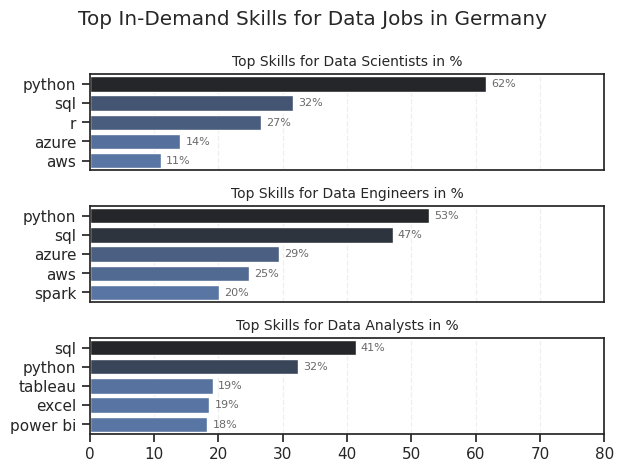

In [59]:
#plotting most required skills for DS,DE & DA
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 80)
    ax[i].set_title(f'Top Skills for {job_title}s in %', fontsize=10)
    ax[i].grid(True, axis='x', linestyle='--', alpha=0.3)
    if i != len(job_titles) - 1:
        ax[i].tick_params(axis='x', which='both', length=0, labelbottom=False)
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 0.8, n, f'{v:.0f}%', va='center', fontsize=8, color='dimgray')
fig.suptitle('Top In-Demand Skills for Data Jobs in Germany')
fig.tight_layout(h_pad=1.0)
plt.show()
